# Digital Transformation and Inclusion in East Africa

### Client
East African Communications Organisation (EACO)

### Data Source
World Bank Indicators API

### Period
2010–2024

### Analytical Objective
To evaluate digital transformation and digital inclusion across selected East African countries and identify priority areas for investment.

### Research Questions

1. Which East African country has experienced the highest growth in internet users between 2010 and 2024?
2. How does internet penetration compare with mobile-phone subscriptions across the selected countries?
3. Is access to electricity associated with higher internet usage?
4. Which country has the largest gap between mobile-phone subscriptions and internet adoption?
5. How does Kenya compare with the other East African countries in terms of digital transformation?
6. Which three policy interventions would accelerate digital inclusion within the East African region?

In [ ]:
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr, linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
# Dictionary for Countries
countries = {
    "BDI": "Burundi",
    "KEN": "Kenya",
    "RWA": "Rwanda",
    "SOM": "Somalia",
    "SSD": "South Sudan",
    "TZA": "Tanzania",
    "UGA": "Uganda"
}

countries

{'BDI': 'Burundi',
 'KEN': 'Kenya',
 'RWA': 'Rwanda',
 'SOM': 'Somalia',
 'SSD': 'South Sudan',
 'TZA': 'Tanzania',
 'UGA': 'Uganda'}

## 1. Data Sources and Indicators

The analysis uses three primary World Bank indicators:

- Internet users (% of population)
- Mobile cellular subscriptions (per 100 people)
- Access to electricity (% of population)

In [ ]:
indicators = {
    "internet_users": "IT.NET.USER.ZS",
    "mobile_subscriptions": "IT.CEL.SETS.P2",
    "electricity_access": "EG.ELC.ACCS.ZS"
}

indicators

{'internet_users': 'IT.NET.USER.ZS',
 'mobile_subscriptions': 'IT.CEL.SETS.P2',
 'electricity_access': 'EG.ELC.ACCS.ZS'}

In [ ]:
url = "https://api.worldbank.org/v2/country/KEN/indicator/IT.NET.USER.ZS"

params = {
    "format": "json",
    "per_page": 100
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)

Status code: 200


In [ ]:
data = response.json()
type(data)

data[0]

data[1][0]

{'indicator': {'id': 'IT.NET.USER.ZS',
  'value': 'Individuals using the Internet (% of population)'},
 'country': {'id': 'KE', 'value': 'Kenya'},
 'countryiso3code': 'KEN',
 'date': '2025',
 'value': None,
 'unit': '',
 'obs_status': '',
 'decimal': 0}

In [ ]:
# API Function
def get_world_bank_data(country_code, indicator_code):
    """
    Retrieve indicator data from the World Bank API.
    """

    url = f"https://api.worldbank.org/v2/country/{country_code}/indicator/{indicator_code}"

    params = {
        "format": "json",
        "per_page": 100
    }

    response = requests.get(url, params=params)

    if response.status_code != 200:
        print(f"API request failed for {country_code}")
        return None

    data = response.json()

    if len(data) < 2:
        return None

    return data[1]

test_data = get_world_bank_data("KEN", "IT.NET.USER.ZS")

len(test_data)

66

In [7]:
# Retrieve Raw Data
raw_data = {}

for indicator_name, indicator_code in indicators.items():

    raw_data[indicator_name] = {}

    for country_code, country_name in countries.items():

        print(f"Downloading {indicator_name} - {country_name}")

        data = get_world_bank_data(
            country_code,
            indicator_code
        )

        raw_data[indicator_name][country_code] = data

In [8]:
# Save raw JSON
import os

os.makedirs("raw_data", exist_ok=True)

In [9]:
for indicator_name in raw_data:

    filename = f"raw_data/{indicator_name}.json"

    with open(filename, "w") as f:
        json.dump(raw_data[indicator_name], f, indent=4)

    print(f"Saved: {filename}")

Saved: raw_data/internet_users.json
Saved: raw_data/mobile_subscriptions.json
Saved: raw_data/electricity_access.json


In [10]:
# API into DataFrames
def api_to_dataframe(data_dict, indicator_name):

    records = []

    for country_code, observations in data_dict.items():

        if observations is None:
            continue

        for obs in observations:

            records.append({
                "country_code": country_code,
                "country": obs["country"]["value"],
                "year": int(obs["date"]),
                indicator_name: obs["value"]
            })

    return pd.DataFrame(records)

In [11]:
internet_df = api_to_dataframe(
    raw_data["internet_users"],
    "internet_users"
)

mobile_df = api_to_dataframe(
    raw_data["mobile_subscriptions"],
    "mobile_subscriptions"
)

electricity_df = api_to_dataframe(
    raw_data["electricity_access"],
    "electricity_access"
)

In [12]:
internet_df.head()

,country_code,country,year,internet_users
0,BDI,Burundi,2025,NaN
1,BDI,Burundi,2024,8.5960
2,BDI,Burundi,2023,7.1723
3,BDI,Burundi,2022,7.1448
4,BDI,Burundi,2021,6.7780


In [13]:
# Shape
print("Internet:", internet_df.shape)
print("Mobile:", mobile_df.shape)
print("Electricity:", electricity_df.shape)

Internet: (462, 4)
Mobile: (462, 4)
Electricity: (462, 4)


In [14]:
# Filter years
internet_df = internet_df[
    internet_df["year"].between(2010, 2024)
]

mobile_df = mobile_df[
    mobile_df["year"].between(2010, 2024)
]

electricity_df = electricity_df[
    electricity_df["year"].between(2010, 2024)
]

In [15]:
# Merge and sort
df = internet_df.merge(
    mobile_df,
    on=["country_code", "country", "year"],
    how="outer"
)

df = df.merge(
    electricity_df,
    on=["country_code", "country", "year"],
    how="outer"
)
df = df.sort_values(
    ["country", "year"]
).reset_index(drop=True)

df.head(20)

,country_code,country,year,internet_users,mobile_subscriptions,electricity_access
0,BDI,Burundi,2010,1.000000,17.896220,5.3
1,BDI,Burundi,2011,1.110000,19.701485,6.2
2,BDI,Burundi,2012,1.220000,22.312777,6.5
3,BDI,Burundi,2013,1.264218,24.300681,6.9
4,BDI,Burundi,2014,1.042392,29.567783,7.0
5,BDI,Burundi,2015,2.000000,45.237925,7.9
6,BDI,Burundi,2016,2.200000,47.669730,8.5
7,BDI,Burundi,2017,2.660749,51.453328,9.3
8,BDI,Burundi,2018,4.019500,53.273694,9.5
9,BDI,Burundi,2019,6.072200,53.299550,9.8


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country_code          105 non-null    str    
 1   country               105 non-null    str    
 2   year                  105 non-null    int64  
 3   internet_users        95 non-null     float64
 4   mobile_subscriptions  101 non-null    float64
 5   electricity_access    105 non-null    float64
dtypes: float64(3), int64(1), str(2)
memory usage: 5.1 KB


# 2. Data Quality Assessment

The retrieved dataset is assessed for:

1. Missing values
2. Duplicate records
3. Data completeness
4. Outliers
5. Data consistency

In [17]:
#Missing Values
missing = df.isnull().sum()

missing

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Values,Missing Percentage
country_code,0,0.00
country,0,0.00
year,0,0.00
internet_users,10,9.52
mobile_subscriptions,4,3.81
electricity_access,0,0.00


In [18]:
# Duplicate Records
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [19]:
country_year_duplicates = df.duplicated(
    subset=["country", "year"]
).sum()

print(
    "Duplicate country-year combinations:",
    country_year_duplicates
)

Duplicate country-year combinations: 0


In [20]:
# Data Types
df.dtypes

country_code                str
country                     str
year                      int64
internet_users          float64
mobile_subscriptions    float64
electricity_access      float64
dtype: object

In [21]:
df["year"] = df["year"].astype(int)

numeric_columns = [
    "internet_users",
    "mobile_subscriptions",
    "electricity_access"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [22]:
missing_by_country = (
    df.groupby("country")[numeric_columns]
    .apply(lambda x: x.isnull().sum())
)

missing_by_country

,internet_users,mobile_subscriptions,electricity_access
country,,,
Burundi,0,1,0
Kenya,0,0,0
Rwanda,0,0,0
"Somalia, Fed. Rep.",3,1,0
South Sudan,7,2,0
Tanzania,0,0,0
Uganda,0,0,0


In [23]:
indicator_completeness = (
    df[numeric_columns].notnull().sum()
    / len(df)
    * 100
)

indicator_completeness

internet_users           90.476190
mobile_subscriptions     96.190476
electricity_access      100.000000
dtype: float64

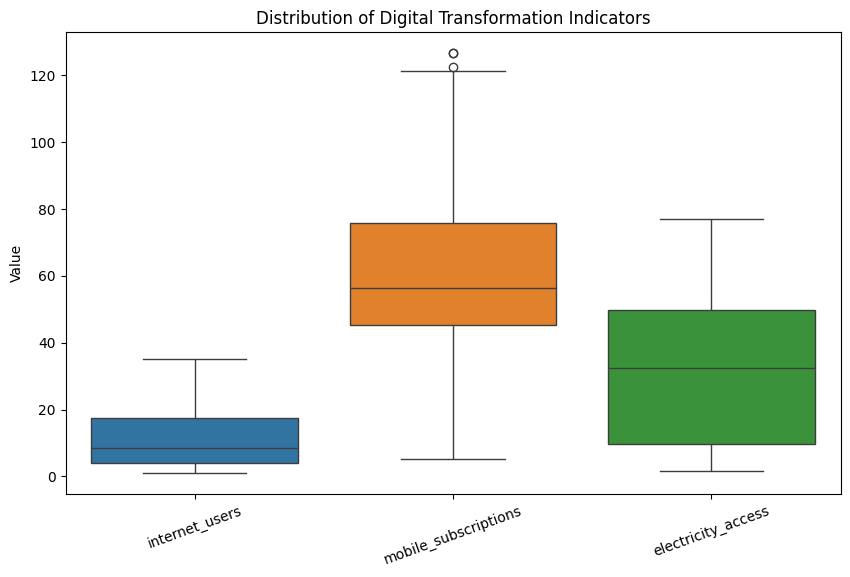

In [24]:
#Outlier Analysis
df[numeric_columns].describe()
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[numeric_columns]
)

plt.title("Distribution of Digital Transformation Indicators")
plt.ylabel("Value")
plt.xticks(rotation=20)
plt.show()

In [25]:
#IQR Detection
def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    return outliers

In [26]:
for column in numeric_columns:

    outliers = detect_outliers_iqr(df, column)

    print(
        column,
        "outliers:",
        len(outliers)
    )

internet_users outliers: 0
mobile_subscriptions outliers: 3
electricity_access outliers: 0


In [27]:
# Data Consistency
df["country"].unique()
sorted(df["year"].unique())
print(
    "Internet users range:",
    df["internet_users"].min(),
    "to",
    df["internet_users"].max()
)

print(
    "Electricity access range:",
    df["electricity_access"].min(),
    "to",
    df["electricity_access"].max()
)
print(
    "Mobile Subscriptions range:",
    df["mobile_subscriptions"].min(),
    "to",
    df["mobile_subscriptions"].max()
)

Internet users range: 1.0 to 34.97622513
Electricity access range: 1.5 to 77.0
Mobile Subscriptions range: 5.28635539640489 to 126.559163217786


In [28]:
clean_df = df.copy()

In [29]:
# Mobile-Internet Gap
clean_df["digital_gap"] = (
    clean_df["mobile_subscriptions"]
    - clean_df["internet_users"]
)
clean_df[
    [
        "country",
        "year",
        "internet_users",
        "mobile_subscriptions",
        "digital_gap"
    ]
].head(20)

,country,year,internet_users,mobile_subscriptions,digital_gap
0,Burundi,2010,1.000000,17.896220,16.896220
1,Burundi,2011,1.110000,19.701485,18.591485
2,Burundi,2012,1.220000,22.312777,21.092777
3,Burundi,2013,1.264218,24.300681,23.036463
4,Burundi,2014,1.042392,29.567783,28.525391
5,Burundi,2015,2.000000,45.237925,43.237925
6,Burundi,2016,2.200000,47.669730,45.469730
7,Burundi,2017,2.660749,51.453328,48.792580
8,Burundi,2018,4.019500,53.273694,49.254194
9,Burundi,2019,6.072200,53.299550,47.227351


In [30]:
# Growth Analysis
growth_df = clean_df[
    clean_df["year"].isin([2010, 2024])
].copy()

internet_growth = growth_df.pivot(
    index="country",
    columns="year",
    values="internet_users"
)

internet_growth

year,2010,2024
country,,
Burundi,1.0,8.596000
Kenya,7.2,34.976225
Rwanda,8.0,31.703300
"Somalia, Fed. Rep.",NaN,27.940201
South Sudan,NaN,NaN
Tanzania,2.9,31.162100
Uganda,4.3,8.949831


In [31]:
internet_growth["percentage_point_change"] = (
    internet_growth[2024]
    - internet_growth[2010]
)
internet_growth["percentage_growth"] = (
    (
        internet_growth[2024]
        - internet_growth[2010]
    )
    / internet_growth[2010]
) * 100
internet_growth.sort_values(
    "percentage_growth",
    ascending=False
)

year,2010,2024,percentage_point_change,percentage_growth
country,,,,
Tanzania,2.9,31.162100,28.262100,974.555132
Burundi,1.0,8.596000,7.596000,759.599972
Kenya,7.2,34.976225,27.776225,385.780905
Rwanda,8.0,31.703300,23.703300,296.291256
Uganda,4.3,8.949831,4.649831,108.135597
"Somalia, Fed. Rep.",NaN,27.940201,NaN,NaN
South Sudan,NaN,NaN,NaN,NaN


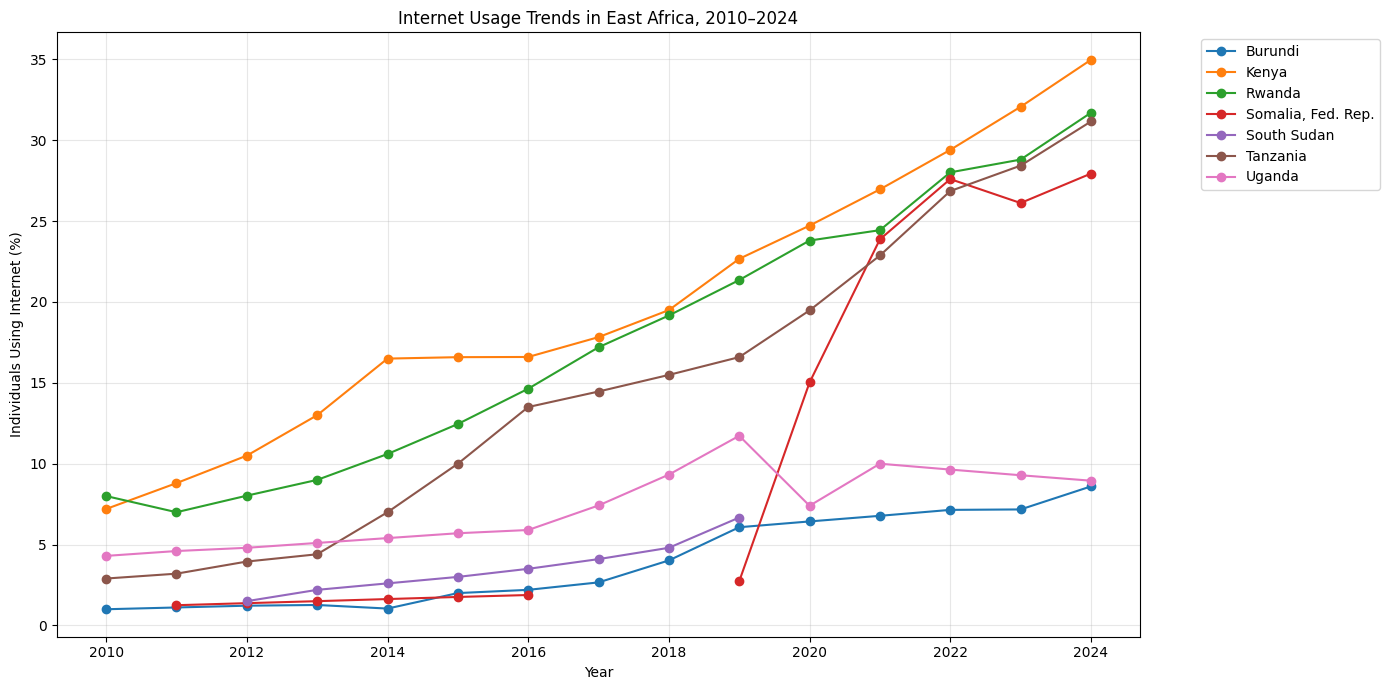

In [32]:
# EDA
plt.figure(figsize=(14, 7))

for country in clean_df["country"].unique():

    country_data = clean_df[
        clean_df["country"] == country
    ]

    plt.plot(
        country_data["year"],
        country_data["internet_users"],
        marker="o",
        label=country
    )

plt.title(
    "Internet Usage Trends in East Africa, 2010–2024"
)

plt.xlabel("Year")
plt.ylabel("Individuals Using Internet (%)")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

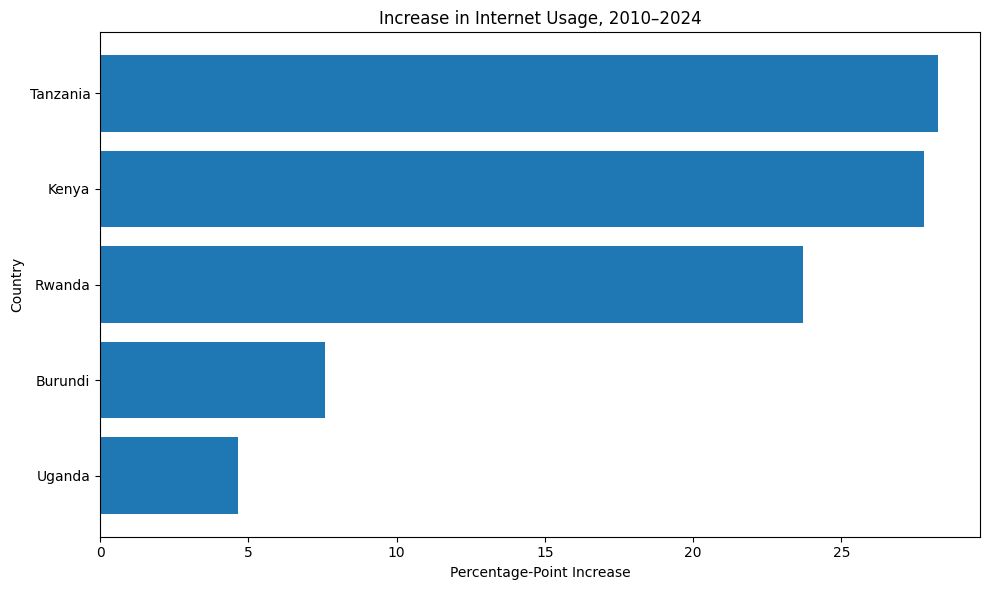

In [33]:
growth_plot = (
    internet_growth
    .sort_values("percentage_point_change")
)

plt.figure(figsize=(10, 6))

plt.barh(
    growth_plot.index,
    growth_plot["percentage_point_change"]
)

plt.title(
    "Increase in Internet Usage, 2010–2024"
)

plt.xlabel("Percentage-Point Increase")

plt.ylabel("Country")

plt.tight_layout()

plt.show()

In [34]:
# Internet vs Mobile(2024)
data_2024 = clean_df[
    clean_df["year"] == 2024
].copy()

data_2024[
    [
        "country",
        "internet_users",
        "mobile_subscriptions"
    ]
]

,country,internet_users,mobile_subscriptions
14,Burundi,8.596000,NaN
29,Kenya,34.976225,126.477706
44,Rwanda,31.703300,93.201463
59,"Somalia, Fed. Rep.",27.940201,NaN
74,South Sudan,NaN,NaN
89,Tanzania,31.162100,126.559163
104,Uganda,8.949831,83.165031


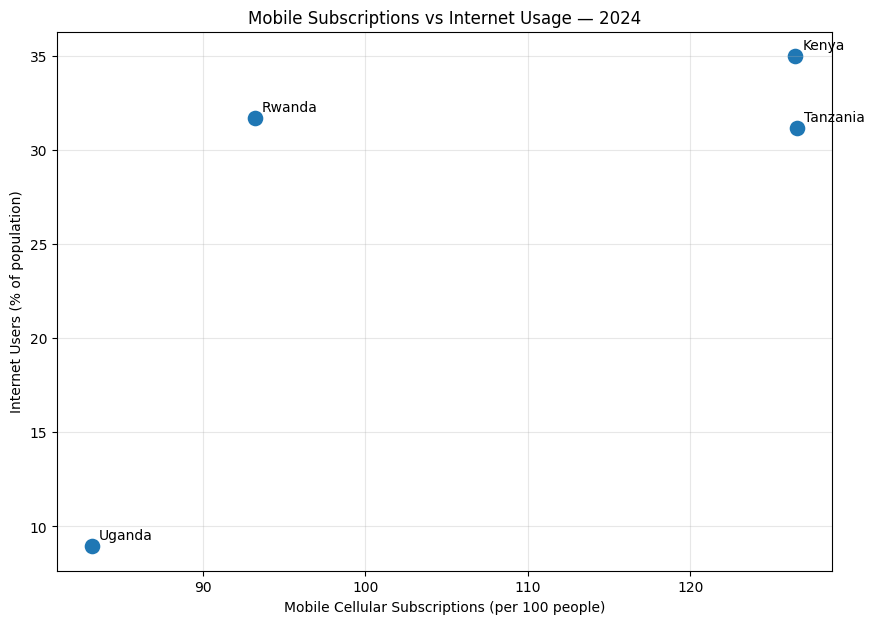

In [35]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=data_2024,
    x="mobile_subscriptions",
    y="internet_users",
    s=150
)

for _, row in data_2024.iterrows():

    plt.annotate(
        row["country"],
        (
            row["mobile_subscriptions"],
            row["internet_users"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title(
    "Mobile Subscriptions vs Internet Usage — 2024"
)

plt.xlabel(
    "Mobile Cellular Subscriptions (per 100 people)"
)

plt.ylabel(
    "Internet Users (% of population)"
)

plt.grid(alpha=0.3)

plt.show()

In [36]:
# Correlation
corr_data = data_2024[
    [
        "mobile_subscriptions",
        "internet_users"
    ]
].dropna()

pearson_mobile = pearsonr(
    corr_data["mobile_subscriptions"],
    corr_data["internet_users"]
)

pearson_mobile

PearsonRResult(statistic=np.float64(0.7465761715436594), pvalue=np.float64(0.2534238284563406))

In [37]:
# Electricity vs Internet
electricity_analysis = data_2024[
    [
        "country",
        "electricity_access",
        "internet_users"
    ]
].dropna()

electricity_analysis

,country,electricity_access,internet_users
14,Burundi,20.1,8.596000
29,Kenya,77.0,34.976225
44,Rwanda,72.0,31.703300
59,"Somalia, Fed. Rep.",54.4,27.940201
89,Tanzania,52.4,31.162100
104,Uganda,55.3,8.949831


In [38]:
r, p = pearsonr(
    electricity_analysis["electricity_access"],
    electricity_analysis["internet_users"]
)

print(f"Pearson correlation: {r:.3f}")
print(f"P-value: {p:.4f}")

Pearson correlation: 0.743
P-value: 0.0909


There is a positive relationship

In [39]:
# Spearman Correlation
rho, p_spearman = spearmanr(
    electricity_analysis["electricity_access"],
    electricity_analysis["internet_users"]
)

print(f"Spearman correlation: {rho:.3f}")
print(f"P-value: {p_spearman:.4f}")

Spearman correlation: 0.771
P-value: 0.0724


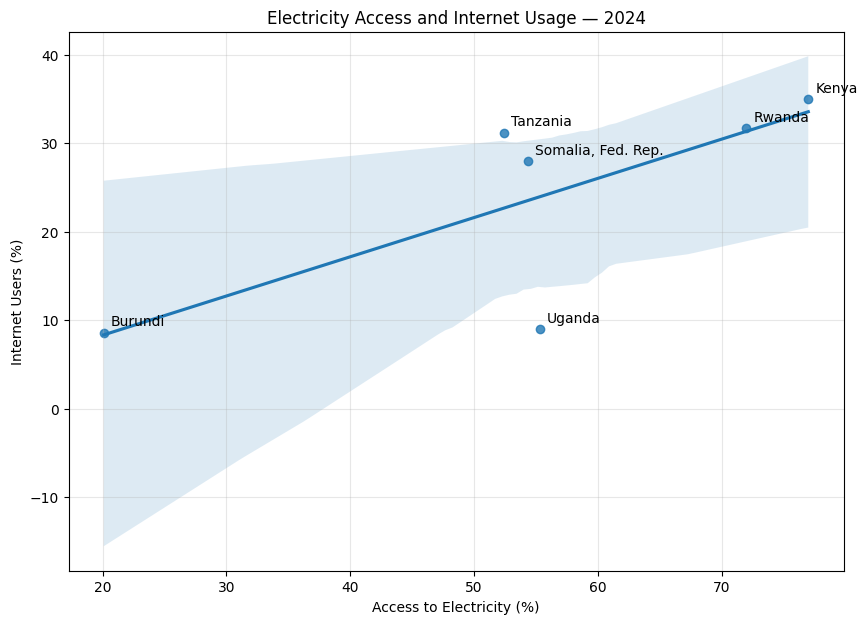

In [40]:
plt.figure(figsize=(10, 7))

sns.regplot(
    data=electricity_analysis,
    x="electricity_access",
    y="internet_users"
)

for _, row in electricity_analysis.iterrows():

    plt.annotate(
        row["country"],
        (
            row["electricity_access"],
            row["internet_users"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title(
    "Electricity Access and Internet Usage — 2024"
)

plt.xlabel(
    "Access to Electricity (%)"
)

plt.ylabel(
    "Internet Users (%)"
)

plt.grid(alpha=0.3)

plt.show()

In [41]:
# Regression Analysis
X = electricity_analysis[
    ["electricity_access"]
]

y = electricity_analysis[
    "internet_users"
]

model = LinearRegression()

model.fit(X, y)
coefficient = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

print("Coefficient:", coefficient)
print("Intercept:", intercept)
print("R-squared:", r_squared)

Coefficient: 0.44278046261839454
Intercept: -0.553538696702045
R-squared: 0.5514330460326745


In [42]:
# Digital Gap
gap_2024 = data_2024[
    [
        "country",
        "mobile_subscriptions",
        "internet_users",
        "digital_gap"
    ]
].sort_values(
    "digital_gap",
    ascending=False
)

gap_2024

,country,mobile_subscriptions,internet_users,digital_gap
89,Tanzania,126.559163,31.162100,95.397063
29,Kenya,126.477706,34.976225,91.501481
104,Uganda,83.165031,8.949831,74.215200
44,Rwanda,93.201463,31.703300,61.498162
14,Burundi,NaN,8.596000,NaN
59,"Somalia, Fed. Rep.",NaN,27.940201,NaN
74,South Sudan,NaN,NaN,NaN


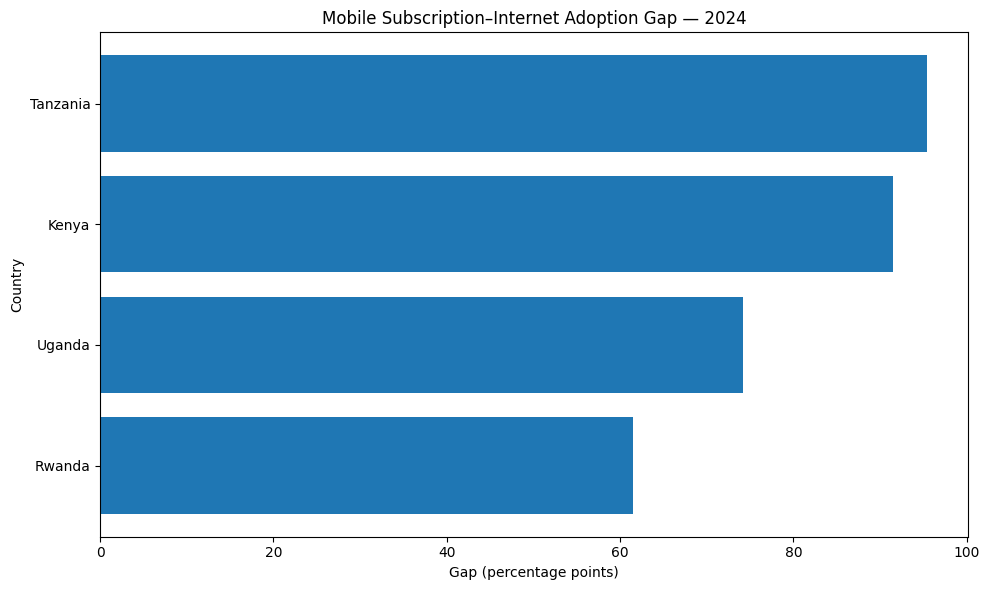

In [43]:
plt.figure(figsize=(10, 6))

plt.barh(
    gap_2024["country"],
    gap_2024["digital_gap"]
)

plt.title(
    "Mobile Subscription–Internet Adoption Gap — 2024"
)

plt.xlabel(
    "Gap (percentage points)"
)

plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [44]:
# Kenya Comparison
kenya = clean_df[
    clean_df["country"] == "Kenya"
]

kenya.tail()

,country_code,country,year,internet_users,mobile_subscriptions,electricity_access,digital_gap
25,KEN,Kenya,2020,24.722799,117.602526,71.5,92.879727
26,KEN,Kenya,2021,26.962900,122.297520,76.5,95.334619
27,KEN,Kenya,2022,29.405899,121.168999,76.0,91.763100
28,KEN,Kenya,2023,32.070400,120.612417,76.2,88.542017
29,KEN,Kenya,2024,34.976225,126.477706,77.0,91.501481


In [45]:
# Regional Averages
regional_average = (
    clean_df
    .groupby("year")[numeric_columns]
    .mean()
    .reset_index()
)

regional_average.tail()

,year,internet_users,mobile_subscriptions,electricity_access
10,2020,16.143000,75.133051,37.857143
11,2021,19.155450,70.947402,40.042857
12,2022,21.444166,74.192747,41.014286
13,2023,21.981250,79.643998,43.885714
14,2024,23.887943,107.350841,48.085714


In [46]:
# Kenya vs Region
kenya_comparison = kenya.merge(
    regional_average,
    on="year",
    suffixes=("_Kenya", "_Regional")
)

kenya_comparison.tail()

,country_code,country,year,internet_users_Kenya,mobile_subscriptions_Kenya,electricity_access_Kenya,digital_gap,internet_users_Regional,mobile_subscriptions_Regional,electricity_access_Regional
10,KEN,Kenya,2020,24.722799,117.602526,71.5,92.879727,16.143000,75.133051,37.857143
11,KEN,Kenya,2021,26.962900,122.297520,76.5,95.334619,19.155450,70.947402,40.042857
12,KEN,Kenya,2022,29.405899,121.168999,76.0,91.763100,21.444166,74.192747,41.014286
13,KEN,Kenya,2023,32.070400,120.612417,76.2,88.542017,21.981250,79.643998,43.885714
14,KEN,Kenya,2024,34.976225,126.477706,77.0,91.501481,23.887943,107.350841,48.085714


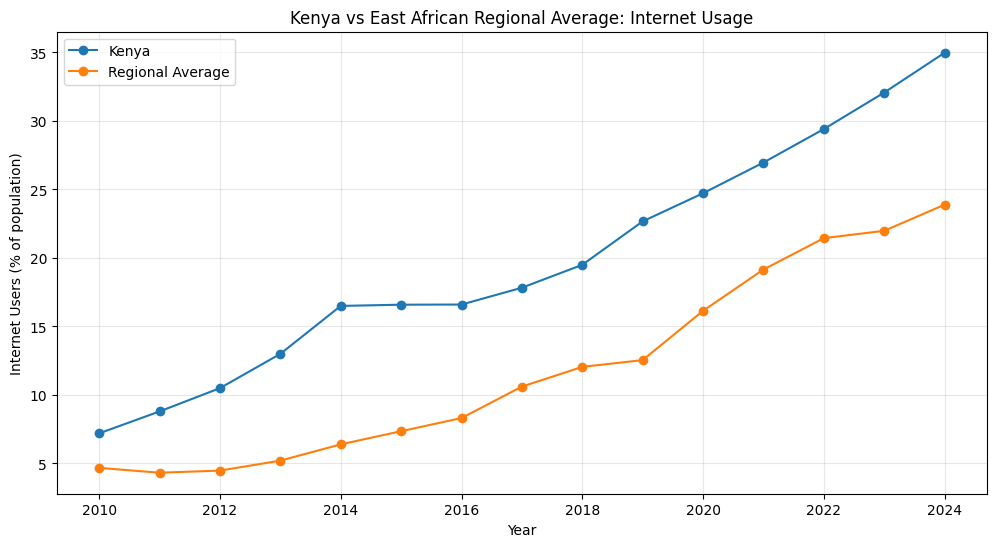

In [47]:
plt.figure(figsize=(12, 6))

plt.plot(
    kenya_comparison["year"],
    kenya_comparison["internet_users_Kenya"],
    marker="o",
    label="Kenya"
)

plt.plot(
    kenya_comparison["year"],
    kenya_comparison["internet_users_Regional"],
    marker="o",
    label="Regional Average"
)

plt.title(
    "Kenya vs East African Regional Average: Internet Usage"
)

plt.xlabel("Year")

plt.ylabel(
    "Internet Users (% of population)"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [48]:
kenya_2024 = data_2024[
    data_2024["country"] == "Kenya"
]

kenya_2024
regional_2024 = data_2024[
    numeric_columns
].mean()

regional_2024
comparison = pd.DataFrame({
    "Indicator": [
        "Internet Users (%)",
        "Mobile Subscriptions",
        "Electricity Access (%)"
    ],
    "Kenya": [
        kenya_2024["internet_users"].iloc[0],
        kenya_2024["mobile_subscriptions"].iloc[0],
        kenya_2024["electricity_access"].iloc[0]
    ],
    "Regional Average": [
        regional_2024["internet_users"],
        regional_2024["mobile_subscriptions"],
        regional_2024["electricity_access"]
    ]
})

comparison

,Indicator,Kenya,Regional Average
0,Internet Users (%),34.976225,23.887943
1,Mobile Subscriptions,126.477706,107.350841
2,Electricity Access (%),77.000000,48.085714


In [49]:
clean_df.to_csv(
    "east_africa_digital_transformation_clean.csv",
    index=False
)
os.path.getsize(
    "east_africa_digital_transformation_clean.csv"
)

6893

In [50]:
from google.colab import files

files.download(
    "east_africa_digital_transformation_clean.csv"
)

ModuleNotFoundError: No module named 'google'

In [ ]:
import shutil

shutil.make_archive(
    "raw_world_bank_data",
    "zip",
    "raw_data"
)
files.download(
    "raw_world_bank_data.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Statistical Analysis
statistical_results = pd.DataFrame({
    "Analysis": [
        "Mobile vs Internet",
        "Electricity vs Internet"
    ],
    "Pearson_r": [
        pearson_mobile[0],
        r
    ],
    "P_value": [
        pearson_mobile[1],
        p
    ]
})

statistical_results

,Analysis,Pearson_r,P_value
0,Mobile vs Internet,0.746576,0.253424
1,Electricity vs Internet,0.742585,0.090865


In [ ]:
# Summary
top_growth_country = (
    internet_growth[
        "percentage_point_change"
    ]
    .idxmax()
)

largest_gap_country = (
    gap_2024
    .iloc[0]["country"]
)

print(
    "Highest internet growth:",
    top_growth_country
)

print(
    "Largest mobile-internet gap:",
    largest_gap_country
)

print(
    "Electricity-internet Pearson correlation:",
    round(r, 3)
)

Highest internet growth: Tanzania
Largest mobile-internet gap: Tanzania
Electricity-internet Pearson correlation: 0.743
